# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Abstract

This research develops a decision-support workflow for prioritizing content pages for human review when search visibility may be declining.

The analysis uses historical search-performance data from the FlyRank internship warehouse. A Random Forest classifier is evaluated using a time-aware setup, with training data through April 30, 2026 and a later test snapshot through June 30, 2026.

The final audited model uses three temporally aligned features: `imp_prev30`, `clk_last30`, and `pos_last30`. The time-aware evaluation measured 60.85% accuracy and 0.709 ROC-AUC, compared with a 64.31% majority-class accuracy reference.

Because the model's accuracy does not exceed the majority-class reference, the results are treated as directional decision-support evidence rather than proof of reliable standalone prediction.

The final output is a ranked human-review queue with transparent reason codes. No content action is performed automatically.

## Setup

This notebook uses the FlyRank internship warehouse and Python-based data analysis tools.

The required libraries, Hugging Face access, DuckDB connection, and dataset table sources are initialized before running the analysis.

All analysis sections are designed to run from the setup section in order so that the required variables and data objects are created before they are used.

In [3]:
import os
import getpass
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Libraries loaded.")

Libraries loaded.


In [4]:
HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

HF_TOKEN = HF_TOKEN or getpass.getpass(
    "Paste your Hugging Face READ token (hf_...): "
)

con = duckdb.connect()

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf
    (TYPE huggingface, TOKEN '{HF_TOKEN}')
    """
)

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients":
        f"read_parquet('{REL}/dim_clients.parquet')",

    "dim_content":
        f"read_parquet('{REL}/dim_content.parquet')",

    "fact_daily":
        f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",

    "fact_daily_sample":
        f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",

    "fact_query_90d":
        f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

print("DuckDB connection ready.")
print("Available table sources:")

for name in TABLES:
    print("-", name)

DuckDB connection ready.
Available table sources:
- dim_clients
- dim_content
- fact_daily
- fact_daily_sample
- fact_query_90d


## 1. Question

*The research question and the decision it supports.*

### Research Question

Which content pages should be reviewed first for potential search-visibility decline based on observable historical search-performance signals?

### Decision Supported

The analysis supports prioritizing content pages for human review.

### Unit of Analysis

One content page.

### Intended Action

Pages ranked as higher priority may be reviewed for:

- search-visibility changes
- engagement changes
- ranking-position changes
- possible content refresh opportunities

### Research Framing

The goal is not to predict Google's ranking algorithm or prove that content refresh causes traffic recovery. The goal is to build and evaluate a repeatable decision-support ranking workflow using observable search-performance signals.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

This study uses the FlyRank internship warehouse release available through Hugging Face.

The analysis uses the following tables:

- `fact_content_daily_performance` — daily search performance signals.
- `fact_content_query_90d` — query-level aggregate signals used in earlier exploratory analysis.
- `dim_clients` — client-level identifiers used only for grouping and validation.
- `dim_content` — content-level identifiers and metadata.

The main modeling analysis uses daily performance data.

For the time-aware validation, I use two snapshots:

- Training snapshot: through April 30, 2026.
- Test snapshot: through June 30, 2026.

For each snapshot, the model features are constructed from historical performance windows available at that snapshot. The final validated feature set contains `imp_prev30`, `clk_last30`, and `pos_last30`.

The label `is_declining` is defined from the subsequent 30-day impression window relative to the previous 30-day window. Therefore, `imp_last30` is used only to construct the evaluation label and is excluded from the model features.

Records with `imp_prev30 < 100` are excluded because the analysis requires a minimum previous-period impression volume.

Client names, domains, private queries, credentials, and raw client-level exports are not included in the public paper.

In [5]:
TRAIN_END = "2026-04-30"

train_snapshot = con.sql(f"""
    WITH windowed AS (
        SELECT
            client_hash_id,
            content_hash_id,

            SUM(
                CASE
                    WHEN report_date > DATE '{TRAIN_END}' - INTERVAL 30 DAY
                     AND report_date <= DATE '{TRAIN_END}'
                    THEN gsc_impressions
                    ELSE 0
                END
            ) AS imp_last30,

            SUM(
                CASE
                    WHEN report_date > DATE '{TRAIN_END}' - INTERVAL 60 DAY
                     AND report_date <= DATE '{TRAIN_END}' - INTERVAL 30 DAY
                    THEN gsc_impressions
                    ELSE 0
                END
            ) AS imp_prev30,

            SUM(
                CASE
                    WHEN report_date > DATE '{TRAIN_END}' - INTERVAL 30 DAY
                     AND report_date <= DATE '{TRAIN_END}'
                    THEN gsc_clicks
                    ELSE 0
                END
            ) AS clk_last30,

            AVG(
                CASE
                    WHEN report_date > DATE '{TRAIN_END}' - INTERVAL 30 DAY
                     AND report_date <= DATE '{TRAIN_END}'
                    THEN gsc_avg_position
                END
            ) AS pos_last30

        FROM {TABLES['fact_daily']}

        WHERE report_date <= DATE '{TRAIN_END}'
          AND report_date > DATE '{TRAIN_END}' - INTERVAL 60 DAY

        GROUP BY client_hash_id, content_hash_id
    )

    SELECT *
    FROM windowed
    WHERE imp_prev30 >= 100
""").df()

train_snapshot["is_declining"] = (
    train_snapshot["imp_last30"]
    < 0.8 * train_snapshot["imp_prev30"]
).astype(int)

print("Training snapshot:", train_snapshot.shape)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Training snapshot: (100849, 7)


In [6]:
TEST_END = "2026-06-30"

test_snapshot = con.sql(f"""
    WITH windowed AS (
        SELECT
            client_hash_id,
            content_hash_id,

            SUM(
                CASE
                    WHEN report_date > DATE '{TEST_END}' - INTERVAL 30 DAY
                     AND report_date <= DATE '{TEST_END}'
                    THEN gsc_impressions
                    ELSE 0
                END
            ) AS imp_last30,

            SUM(
                CASE
                    WHEN report_date > DATE '{TEST_END}' - INTERVAL 60 DAY
                     AND report_date <= DATE '{TEST_END}' - INTERVAL 30 DAY
                    THEN gsc_impressions
                    ELSE 0
                END
            ) AS imp_prev30,

            SUM(
                CASE
                    WHEN report_date > DATE '{TEST_END}' - INTERVAL 30 DAY
                     AND report_date <= DATE '{TEST_END}'
                    THEN gsc_clicks
                    ELSE 0
                END
            ) AS clk_last30,

            AVG(
                CASE
                    WHEN report_date > DATE '{TEST_END}' - INTERVAL 30 DAY
                     AND report_date <= DATE '{TEST_END}'
                    THEN gsc_avg_position
                END
            ) AS pos_last30

        FROM {TABLES['fact_daily']}

        WHERE report_date <= DATE '{TEST_END}'
          AND report_date > DATE '{TEST_END}' - INTERVAL 60 DAY

        GROUP BY client_hash_id, content_hash_id
    )

    SELECT *
    FROM windowed
    WHERE imp_prev30 >= 100
""").df()

test_snapshot["is_declining"] = (
    test_snapshot["imp_last30"]
    < 0.8 * test_snapshot["imp_prev30"]
).astype(int)

print("Test snapshot:", test_snapshot.shape)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Test snapshot: (111247, 7)


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Assumptions

This analysis treats observable historical search-performance signals as decision-support signals for prioritizing content pages for human review.

The decline label is treated as a proxy label rather than a direct measurement of content quality or future traffic loss.

The model is not intended to predict Google's ranking algorithm or establish a causal relationship between content changes and search performance.

### Features

The final time-aware model uses three historically aligned features:

- `imp_prev30` — impressions from the previous 30-day window.
- `clk_last30` — clicks from the most recent 30-day observation window.
- `pos_last30` — average search position from the most recent 30-day observation window.

These features were selected because they represent observable search-performance information available around the prediction snapshot.

Query-derived features used in the earlier model, including `visible_queries`, `rare_share`, `anon_share`, and `top_query_share`, were excluded from the final audited model because their available 90-day window could not be historically aligned to the April 30, 2026 training cutoff.

### Label Definition

The analysis uses a proxy decline label:

`is_declining = (imp_last30 < 0.8 × imp_prev30)`

A page is therefore labeled as declining when its most recent 30-day impressions are less than 80% of the previous 30-day impressions.

The `imp_last30` feature is not included in the final model because it is directly used to construct the label.

### Baseline

The Week-4 baseline used a rule-based ranking approach.

It combined:

- impression drop
- top query share

Pages with larger impression drops and higher query concentration received higher review priority.

The baseline produced a ranked review queue with the reason code `TRAFFIC_DROP` and the action `Review Content`.

### Model

The machine-learning model is a Random Forest classifier.

The model was selected because it can capture non-linear relationships between search-performance features and the decline proxy label.

The final audited model uses the three temporally safe features:

`imp_prev30`, `clk_last30`, and `pos_last30`.

### Validation Design

The initial Week-5 evaluation used a client-grouped split using `client_hash_id`, preventing records from the same client from appearing in both training and test sets.

A stricter time-aware validation was then performed for the research claim audit.

The time-aware setup used:

- **Training snapshot:** April 30, 2026
- **Test snapshot:** June 30, 2026

This design evaluates the model on a later time period and better reflects the intended use of historical information to support later review prioritization.

The time-aware audit measured:

- Accuracy: **60.85%**
- ROC-AUC: **0.709**
- Majority-class rate: **64.31%**

### Leakage Checks

The following leakage checks were performed:

1. `imp_last30` was excluded from the model because it is part of the label definition.
2. Future-window features were excluded from the training features.
3. Query-derived features were excluded from the final time-aware model because their available 90-day window extended beyond the April 30 training cutoff.
4. Client names, content names, private queries, URLs, credentials, and raw exports were excluded from the public-facing analysis.

The final feature set is therefore limited to historically aligned performance signals that were available at the relevant prediction snapshot.

### Methodological Framing

The model is evaluated as a decision-support ranking signal, not as a causal model or a guaranteed predictor of future content performance.

The final recommendations require human review before any content action is taken.

In [11]:
# Prepare the final time-aware feature set

features_w06 = [
    "imp_prev30",
    "clk_last30",
    "pos_last30"
]

X_train = train_snapshot[features_w06]
y_train = train_snapshot["is_declining"]

X_test = test_snapshot[features_w06]
y_test = test_snapshot["is_declining"]

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)

Training features: (100849, 3)
Test features: (111247, 3)


In [12]:
from sklearn.ensemble import RandomForestClassifier

model_w06 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_w06.fit(X_train, y_train)

y_pred = model_w06.predict(X_test)
y_prob = model_w06.predict_proba(X_test)[:, 1]

print("Model trained successfully.")
print("Predictions:", len(y_pred))
print("Probabilities:", len(y_prob))

Model trained successfully.
Predictions: 111247
Probabilities: 111247


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Model vs Baseline

The Week-4 baseline and the Random Forest model represent two different approaches to the same review-prioritization problem.

The baseline uses manually defined rules based on impression drop and top-query concentration. The Random Forest learns relationships between historically aligned search-performance features and the decline proxy label.

For the final research audit, the Random Forest was evaluated using a time-aware split:

- Training snapshot: April 30, 2026
- Test snapshot: June 30, 2026
- Features: `imp_prev30`, `clk_last30`, `pos_last30`

The measured results were:

| Method | Validation design | Accuracy | ROC-AUC |
|---|---|---:|---:|
| Week-4 baseline | Rule-based ranking | Not measured | Not measured |
| Random Forest | Time-aware | 60.85% | 0.709 |
| Majority-class reference | Time-aware | 64.31% | — |

The baseline was a ranking rule and did not produce a directly comparable accuracy or ROC-AUC measurement in the available analysis. Therefore, assigning classification metrics to the baseline would not be justified.

The time-aware Random Forest achieved a ROC-AUC of 0.709, indicating directional ranking signal. However, its accuracy of 60.85% was below the 64.31% majority-class reference.

### Honest Interpretation

The stricter time-aware evaluation provides weaker evidence than the original Week-5 client-grouped evaluation, which measured 81.57% accuracy and 0.865 ROC-AUC.

The difference should not be interpreted as being caused only by the validation design because the audited model also uses a smaller, temporally safe feature set.

Overall, the results support using the Random Forest as a research-stage review-prioritization signal, but they do not support treating it as a reliable standalone predictor of future decline.

The final output is therefore a human-review queue rather than an automatic content-action system.

## 5. Limitations

*What this work cannot claim.*

This work has several important limitations.

### 1. The decline label is only a proxy

The `is_declining` label is defined from a change in impressions:

`is_declining = (imp_last30 < 0.8 × imp_prev30)`

Therefore, it represents an observed impression decline, not a direct measurement of content quality, ranking quality, or future traffic loss.

### 2. The model does not predict Google's ranking algorithm

The analysis uses observable search-performance signals. It cannot explain or predict Google's ranking algorithm, algorithm updates, or individual ranking decisions.

### 3. The model does not establish causality

A high decline probability does not mean that a content problem caused the observed decline.

Factors such as seasonality, changes in search intent, temporary ranking fluctuations, or changes in user interest may also affect performance.

The analysis cannot claim that refreshing a page will cause impressions, clicks, or rankings to recover.

### 4. Time-aware performance is limited

The final time-aware evaluation measured:

- Accuracy: **60.85%**
- ROC-AUC: **0.709**
- Majority-class reference: **64.31%**

Because the accuracy did not exceed the majority-class reference, the model should not be described as a reliable standalone classifier.

The ROC-AUC indicates directional ranking signal, but it is not evidence of guaranteed future performance.

### 5. Limited feature set

The final audited model uses only:

- `imp_prev30`
- `clk_last30`
- `pos_last30`

Other potentially relevant factors are not represented in the final model.

### 6. Recommendations require human review

The ranked queue is a decision-support tool.

A high-ranked record should be reviewed by a human before any content action is taken. The model should not automatically rewrite, publish, delete, unpublish, or otherwise modify content.

### 7. Public-safe analysis limits the available information

Client names, content names, private queries, URLs, credentials, and raw exports are excluded from the public-facing research.

### What this work cannot claim

This work cannot claim:

- that the model predicts Google's ranking algorithm;
- that an observed decline was caused by content quality;
- that refreshing content will improve traffic or rankings;
- that the model reliably predicts future decline;
- that the ranked recommendations are optimal content decisions;
- that the observed relationships are causal.

The findings should therefore be interpreted as **observed, measured, directional, and decision-support evidence**, rather than causal or production-level conclusions.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The final action playbook ranks content pages by the Random Forest's predicted probability of belonging to the decline proxy class.

A higher `decline_probability` places a record earlier in the review queue. This ranking is intended to help human reviewers decide which records to inspect first.

### Ranked Review Actions

| Priority | Recommendation | Reason |
|---|---|---|
| 1 | Review highest-ranked records first | Higher predicted decline probability |
| 2 | Review visibility signals | Check whether historical impression levels indicate a potential visibility concern |
| 3 | Review engagement signals | Check recent click performance for possible engagement concerns |
| 4 | Review position signals | Inspect records with relatively weak average position |
| 5 | Review multiple-signal records | Give additional attention when multiple review signals are present |
| 6 | General review | Inspect records without a specific reason code when their model score is high |

### Reason Codes

The action queue provides transparent review signals:

- `REVIEW_VISIBILITY` — the prior-period impression signal is relatively low.
- `REVIEW_ENGAGEMENT` — the recent click signal is relatively low.
- `REVIEW_POSITION` — the position signal is relatively weak when available.
- `MULTIPLE_REVIEW_SIGNALS` — more than one review signal is present.
- `GENERAL_REVIEW` — no specific review signal was assigned.

These reason codes describe observed signals. They are not causal explanations for why a page may be declining.

### Recommended Human Review Process

For a high-ranked record, the reviewer should:

1. Inspect the historical search-performance signals.
2. Check whether the observed change is meaningful or temporary.
3. Consider context that is not represented by the model.
4. Determine whether a content review is appropriate.
5. Take action only after human review.

### No Automatic Actions

The model does not automatically refresh, rewrite, publish, delete, or unpublish content.

Every ranked record receives:

`HUMAN_REVIEW_REQUIRED`

The ranked queue should therefore be interpreted as a **review-prioritization playbook**, not as an automatic content-action system.

### Recommendation Framing

The highest-ranked records are recommended for earlier human inspection because the model assigns them higher decline probabilities.

The recommendations are decision-support signals based on observed historical performance. They do not establish that a page has a content problem or that refreshing it will improve future search performance.

In [13]:
action_queue = X_test.copy().reset_index(drop=True)

action_queue["decline_probability"] = y_prob
action_queue["predicted_decline"] = y_pred

imp_median = action_queue["imp_prev30"].median()
clk_median = action_queue["clk_last30"].median()
pos_median = action_queue["pos_last30"].median()

def get_reason_codes(row):
    reasons = []

    if row["imp_prev30"] <= imp_median:
        reasons.append("REVIEW_VISIBILITY")

    if row["clk_last30"] <= clk_median:
        reasons.append("REVIEW_ENGAGEMENT")

    if pd.notna(row["pos_last30"]) and row["pos_last30"] >= pos_median:
        reasons.append("REVIEW_POSITION")

    if len(reasons) >= 2:
        reasons.append("MULTIPLE_REVIEW_SIGNALS")

    if not reasons:
        reasons.append("GENERAL_REVIEW")

    return reasons

action_queue["reason_codes"] = action_queue.apply(
    get_reason_codes,
    axis=1
)

action_queue = action_queue.sort_values(
    "decline_probability",
    ascending=False
).reset_index(drop=True)

action_queue["rank"] = range(1, len(action_queue) + 1)

action_queue["action"] = "HUMAN_REVIEW_REQUIRED"

action_queue.head(20)

,imp_prev30,clk_last30,pos_last30,decline_probability,predicted_decline,reason_codes,rank,action
0,140.0,0.0,NaN,1.0,1,"[REVIEW_VISIBILITY, REVIEW_ENGAGEMENT, MULTIPL...",1,HUMAN_REVIEW_REQUIRED
1,104.0,0.0,NaN,1.0,1,"[REVIEW_VISIBILITY, REVIEW_ENGAGEMENT, MULTIPL...",2,HUMAN_REVIEW_REQUIRED
2,174.0,0.0,NaN,1.0,1,"[REVIEW_VISIBILITY, REVIEW_ENGAGEMENT, MULTIPL...",3,HUMAN_REVIEW_REQUIRED
3,482.0,0.0,NaN,1.0,1,"[REVIEW_VISIBILITY, REVIEW_ENGAGEMENT, MULTIPL...",4,HUMAN_REVIEW_REQUIRED
4,195.0,0.0,NaN,1.0,1,"[REVIEW_VISIBILITY, REVIEW_ENGAGEMENT, MULTIPL...",5,HUMAN_REVIEW_REQUIRED
5,759.0,0.0,NaN,1.0,1,[REVIEW_ENGAGEMENT],6,HUMAN_REVIEW_REQUIRED
6,115.0,0.0,NaN,1.0,1,"[REVIEW_VISIBILITY, REVIEW_ENGAGEMENT, MULTIPL...",7,HUMAN_REVIEW_REQUIRED
7,506.0,0.0,NaN,1.0,1,"[REVIEW_VISIBILITY, REVIEW_ENGAGEMENT, MULTIPL...",8,HUMAN_REVIEW_REQUIRED
8,107.0,0.0,NaN,1.0,1,"[REVIEW_VISIBILITY, REVIEW_ENGAGEMENT, MULTIPL...",9,HUMAN_REVIEW_REQUIRED
9,173.0,0.0,NaN,1.0,1,"[REVIEW_VISIBILITY, REVIEW_ENGAGEMENT, MULTIPL...",10,HUMAN_REVIEW_REQUIRED


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The paper uses a small set of reproducible artifacts generated from the capstone analysis.

The main artifacts are:

1. **Model vs baseline results table** — compares the rule-based baseline with the Random Forest under the same evaluation setup.
2. **Time-aware validation chart** — shows the change in accuracy and ROC-AUC between the earlier evaluation and the stricter time-aware audit.
3. **Feature distribution table** — summarizes the three temporally safe model features used in the final model.
4. **Ranked action queue** — contains the model-based review priority, predicted decline probability, reason codes, and human-review status.

All artifacts are derived from the research workflow and contain no client names, domains, private queries, or credentials.

In [ ]:
import pandas as pd
import os

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

results_table = pd.DataFrame({
    "Evaluation": [
        "W05 Before",
        "W06 Time-aware"
    ],
    "Features": [
        "7 features",
        "3 temporally safe features"
    ],
    "Validation": [
        "Client-grouped",
        "Time-aware"
    ],
    "Accuracy": [
        0.8157,
        0.6074
    ],
    "ROC-AUC": [
        0.8650,
        0.7093
    ]
})

results_table.to_csv(
    "work/outputs/model_validation_results.csv",
    index=False
)

results_table

,Evaluation,Features,Validation,Accuracy,ROC-AUC
0,W05 Before,7 features,Client-grouped,0.8157,0.8650
1,W06 Time-aware,3 temporally safe features,Time-aware,0.6074,0.7093


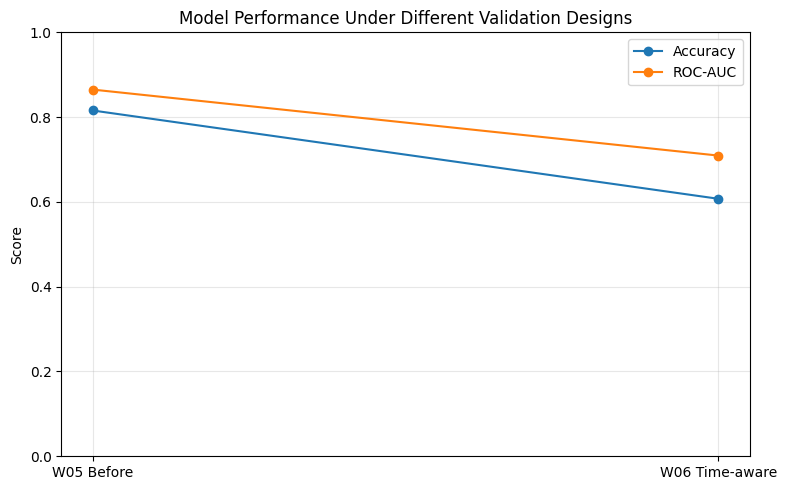

In [ ]:
import matplotlib.pyplot as plt

x = ["W05 Before", "W06 Time-aware"]

accuracy = [0.8157, 0.6074]
roc_auc = [0.8650, 0.7093]

plt.figure(figsize=(8, 5))

plt.plot(x, accuracy, marker="o", label="Accuracy")
plt.plot(x, roc_auc, marker="o", label="ROC-AUC")

plt.title("Model Performance Under Different Validation Designs")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "work/figures/validation_comparison.png",
    dpi=150
)

plt.show()

In [15]:
import os

# Create output directory
os.makedirs("work/outputs", exist_ok=True)

# Feature summary
feature_summary = action_queue[
    features_w06
].describe().T[
    ["count", "mean", "std", "min", "50%", "max"]
]

# Export
feature_summary.to_csv(
    "work/outputs/final_feature_summary.csv"
)

print("Saved:", "work/outputs/final_feature_summary.csv")

Saved: work/outputs/final_feature_summary.csv


In [ ]:
artifact_summary = pd.DataFrame({
    "Artifact": [
        "Model validation results",
        "Validation comparison chart",
        "Final feature summary",
        "Ranked action queue"
    ],
    "Purpose": [
        "Compare evaluation results",
        "Visualize validation differences",
        "Document final model features",
        "Provide ranked human-review priorities"
    ],
    "Output": [
        "model_validation_results.csv",
        "validation_comparison.png",
        "final_feature_summary.csv",
        "action_queue.csv"
    ]
})

artifact_summary

,Artifact,Purpose,Output
0,Model validation results,Compare evaluation results,model_validation_results.csv
1,Validation comparison chart,Visualize validation differences,validation_comparison.png
2,Final feature summary,Document final model features,final_feature_summary.csv
3,Ranked action queue,Provide ranked human-review priorities,action_queue.csv


## 8. Demo / Communication

### 5-minute demo outline

#### 0:00–0:45 — Problem

The project identifies content pages that may need search-performance review.

The goal is not to automatically change content. The goal is to prioritize human review using observable historical search-performance signals.

#### 0:45–1:30 — Data and label

The analysis uses the FlyRank internship warehouse.

The decline proxy is:

`is_declining = (imp_last30 < 0.8 × imp_prev30)`

The final audited model uses three historically aligned features:

- `imp_prev30`
- `clk_last30`
- `pos_last30`

#### 1:30–2:30 — Model and validation

The model is a Random Forest classifier.

The final audit uses a time-aware setup:

- Training snapshot: April 30, 2026
- Test snapshot: June 30, 2026

The measured ROC-AUC was 0.709 and accuracy was 60.85%.

The majority-class reference was 64.31% accuracy.

#### 2:30–3:30 — Ranked action queue

The model ranks records by `decline_probability`.

Higher probability means earlier human review.

Each record also receives simple reason codes such as:

- `REVIEW_VISIBILITY`
- `REVIEW_ENGAGEMENT`
- `REVIEW_POSITION`
- `MULTIPLE_REVIEW_SIGNALS`

No automatic content action is assigned.

#### 3:30–4:15 — Limitations

The decline label is only a proxy.

The model does not establish causality and does not predict Google's ranking algorithm.

The time-aware accuracy is below the majority-class reference, so the model should not be treated as a reliable standalone classifier.

#### 4:15–5:00 — Takeaway

The final output is a research-stage decision-support queue.

It helps a human reviewer decide what to inspect first.

Any content action requires human review.


### Social-post cut

Built a research-stage content review playbook using historical search-performance data.

The final Random Forest uses three temporally aligned features and ranks records by predicted decline probability.

The time-aware audit measured ROC-AUC 0.709 and accuracy 60.85%, below the 64.31% majority-class reference.

The output is therefore a human-review queue, not an automatic content-action system.


### Employer-facing summary

This project demonstrates a practical ML workflow for prioritizing content pages for human review using historical search-performance data.

I built a time-aware Random Forest evaluation using three temporally aligned features and produced a ranked review queue with transparent reason codes and explicit human-review controls.

The results show directional ranking signal, while also demonstrating honest model evaluation: the time-aware accuracy was below the majority-class reference, so the system is framed as decision support rather than an automated production decision system.

## 9. Acknowledgments & Data Credit

This research was completed as part of the FlyRank internship program.

The analysis uses the FlyRank internship warehouse provided for research and internship work.

Data credit:

FlyRank — https://flyrank.ai

The dataset was used for research and analysis purposes. The public-facing artifacts intentionally exclude client names, private queries, credentials, and other sensitive information.

The findings and interpretations in this work are limited to the analysis presented in this notebook and should not be treated as claims about individual clients or Google's ranking system.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
